In [2]:
# Importamos librerias
from scipy.special import legendre
import numpy as np
import matplotlib.pyplot as plt
import time
from fenics import *
from dolfin_adjoint import *
import pandas as pd
from moola import *

In [3]:
# Cálculo de las funciones base ϕ
# Notar que las funciones base NO son los polinomios de Legendre tal cual, sino una resta de ellos
def phi(n,x):
    pol_list1 = list(legendre(n))
    pol1 = []
    for i in range(n+1):
        pol1.append(pol_list1[i]*x**(n-i))
    pol_list2 = list(legendre(n+2))
    pol2 = []
    for i in range(n+3):
        pol2.append(pol_list2[i]*x**(n+2-i))
    return (1/(2*(n+1)+1))*(sum(pol1) - sum(pol2))

In [4]:
class KdV_Equation(object):
    # Inicialización de parámetros
    def __init__(self, N, dt, T, f, u0):
        self.N = N
        self.dt = dt
        self.T = T
        self.f = f
        self.u0 = u0
        self.sol = []
        
    # Cálculo de la matriz L
    def calcul_mat_L(self, N):
        diag_list = []
        for m in range(0,N-2):
            diag_list.append(2/(2*(m+1)+1))
        return np.diag(diag_list)

    # Cálculo de la matriz M
    def calcul_mat_M(self, N):
        c = lambda n : 1/(2*n+1)
        M = np.zeros((N-2,N-2))
        for m in range(0,N-2):
            for n in range(0,N-2):
                if m == n:
                    M[m][n] = 2*(c(m+1))**2*(c(m)+c(m+2))
                    #M[n][m] = 2*(c(m+1))**2*(c(m)+c(m+2))
                if n == m+1:
                    #M[m][n] = -2*c(m+1)*(c(m+2)**2)*(c(m)+(m+3)*c(m+3))
                    M[m][n] = 2*c(m+1)*c(m+2)*(-c(m)*c(m+1)*(m+1) + c(m+1)*c(m+2)*(m+2) - c(m+2)*c(m+3)*(m+3))
                    #M[n][m] = -2*c(m+1)*(c(m+2)**2)*(c(m)+(m+3)*c(m+3))
                if n == m+2:
                    M[m][n] = -2*c(m+1)*c(m+2)*c(m+3)
                    #M[n][m] = -2*c(m+1)*c(m+2)*c(m+3)
                if n == m+3:
                    M[m][n] = 2*(m+3)*c(m+1)*c(m+2)*c(m+3)*c(m+4)
                    #M[n][m] = 2*(m+3)*c(m+1)*c(m+2)*c(m+3)*c(m+4)
                M[n][m] = M[m][n]
        return M

    # Cálculo de la matriz Q
    def calcul_mat_Q(self, N):
        Q = np.zeros((N-2,N-2))
        for m in range(0,N-2):
            for n in range(0,N-2):
                if m == n:
                    Q[m][n] = 1/(2*(m+1)+1) - 1
                if n >= m + 1:
                    Q[m][n] = 2*(-1)**(m+n+1)
        return Q

    # Cálculo de los coeficientes iniciales de u_{n}^{0} para empezar el cálculo de las soluciones en cada instante
    # NOTA: NO son los valores de la solución inicial, sino los valores de los coeficientes asociados en su descomposición por ϕ's
    def u_0_hat(self,N, inv_base_matrix):
        init_u = []
        for i in range(1,N-1):
            init_u.append(self.u0(i))
        return inv_base_matrix @ np.array(init_u)

    # Cálculo de los coeficientes f_{k}^{n} para empezar el llamado recursivo
    # NOTA: NO son los valores de la función f, sino los valores de los coeficientes asociados en su descomposición por ϕ's
    def f_hat_values(self, N, k, inv_base_matrix):
        f_vect = []
        for i in range(1,N-1):
            f_vect.append((self.f(i, k+1) + self.f(i, k))/2)
        return inv_base_matrix @ f_vect

    # Creación de la matriz de ϕ's para cada valor de x
    def create_base_matrix(self,N, x_space):
        x = x_space
        pol_mat = np.zeros((N-2,N-2))
        for x_index in range(1,N-1):
            for n_index in range(0,N-2):
                pol_mat[x_index-1][n_index] = (1-x[x_index])*phi(n_index,x[x_index])
        return pol_mat

    # Inicia el proceso de elementos finitos
    def finite_element(self):
        N = self.N
        dt = self.dt
        L = self.calcul_mat_L(N)
        M = self.calcul_mat_M(N)
        Q = self.calcul_mat_Q(N)
        A = M + dt*L - (dt/2)*Q
        #print("DETERMINANTE DE A:", np.linalg.det(A))
        #print("NRO CONDICION DE A:", np.linalg.cond(A))
        inv_A = np.linalg.inv(A)
        #print(A @ inv_A)
        #print(inv_A @ A)
        B = M - dt*L + (dt/2)*Q
        C = dt*M
        print(np.linalg.norm(A-B))
        k = 0
        u_hat_list = []
        u_list = []
        x_space = np.linspace(-1,1,N)
        print(len(x_space))
        base_matrix = self.create_base_matrix(N,x_space)
        inv_base_matrix = np.linalg.inv(base_matrix)
        u_hat_list.append(self.u_0_hat(self.N, inv_base_matrix))
        u_list.append(base_matrix @ u_hat_list[0])
        # Empieza el ciclo para calcular los coeficientes asociados a la descomposición de las soluciones en cada instante
        while (k*dt < self.T):
            F = self.f_hat_values(N,k,inv_base_matrix)
            right_side = B @ u_hat_list[k] + C @ F
            u_k_hat = inv_A @ right_side
            u_hat_list.append(u_k_hat)
            u_k = base_matrix @ u_k_hat
            u_list.append(u_k)
            k+=1
        return u_list

In [5]:
N = 40
dt = 0.0000001
T = 0.0001
x = np.linspace(-1,1,N)

a = np.pi
b = 12
c = 12
alpha = 1
beta = 0
u0 = lambda i : (np.sin(a*x[i])**2) * np.sin(b*x[i])
f = lambda i, k : ((c-b**3*alpha)*np.sin(a*x[i])**2 + 6*a**2*b*alpha*np.cos(2*a*x[i]))*np.cos(b*x[i] + c*k*dt) - a*alpha*(4*a**2 + 3*b**2)*np.sin(2*a*x[i])*np.sin(b*x[i]+c*k*dt)#+beta*(-1*(2*a**2*np.cos(2*a*x[i])-b**2*np.sin(a*x[i])**2*np.sin(b*x[i]+c*k*dt)-2*a*b*np.sin(2*a*x[i])*np.cos(b*x[i]+c*k*dt)))
#f = 0

kdv_linear_equation = KdV_Equation(N,dt,T,f,u0)
u_aprox = kdv_linear_equation.finite_element()

sol_exact = lambda i, k : np.sin(a*x[i])**2 * np.sin(b*x[i] + c*k*dt)


5.350632591566983e-06
40


In [6]:
type(u_aprox)

list

In [7]:
k = 0
while(k*dt < T):
    u_exact = [sol_exact(i,k) for i in range(0,N)]
    '''
    plt.plot(x, np.concatenate([[0],u_aprox[k],[0]]),color="red")
    #plt.plot(x[1:-1], u_aprox[k], color="red")
    plt.plot(x, u_exact)
    plt.title(f"Gráfico dinámico para la solución de la ecuación KdV con dt: {dt}", pad=18)
    plt.xlabel(f"Eje x - Tiempo: {round(k*dt, 5)} seg")
    plt.ylabel("Valores de la función solución obtenida")
    plt.xlim(-1,1)
    plt.ylim(-1,1)
    plt.grid()
    plt.pause(1e-10)
    plt.clf()
    '''
    k+=1
#plt.show()

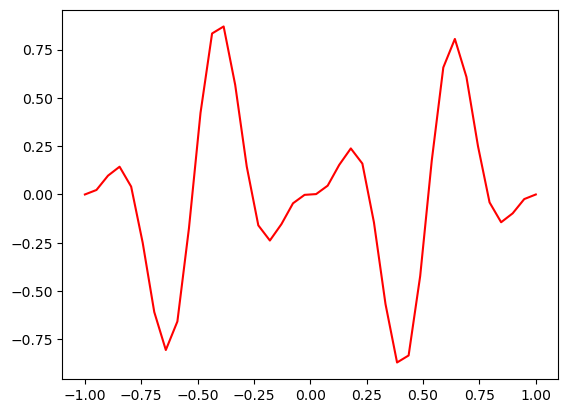

In [8]:
plt.plot(x, np.concatenate([[0],u_aprox[2],[0]]),color="red")

In [9]:
x

array([-1.        , -0.94871795, -0.8974359 , -0.84615385, -0.79487179,
       -0.74358974, -0.69230769, -0.64102564, -0.58974359, -0.53846154,
       -0.48717949, -0.43589744, -0.38461538, -0.33333333, -0.28205128,
       -0.23076923, -0.17948718, -0.12820513, -0.07692308, -0.02564103,
        0.02564103,  0.07692308,  0.12820513,  0.17948718,  0.23076923,
        0.28205128,  0.33333333,  0.38461538,  0.43589744,  0.48717949,
        0.53846154,  0.58974359,  0.64102564,  0.69230769,  0.74358974,
        0.79487179,  0.84615385,  0.8974359 ,  0.94871795,  1.        ])

In [10]:
u_select=u_aprox[2].tolist()

In [11]:
u_select

[0.023290616358335115,
 0.0975299163485989,
 0.1438117653596575,
 0.04092085557826424,
 -0.2501469955311188,
 -0.6087795440150067,
 -0.8055780419816239,
 -0.6577903167938465,
 -0.17482827509330318,
 0.4225671156520405,
 0.8338701678284175,
 0.8701457515974999,
 0.5675998908593141,
 0.14438456151099185,
 -0.15998211479655258,
 -0.2384612635165182,
 -0.15355710710221848,
 -0.04567165453953886,
 -0.0019617446719586624,
 0.0019613247969686143,
 0.0456727835511892,
 0.15355669204791605,
 0.23846008976358812,
 0.15998111098023274,
 -0.1443879374513891,
 -0.5676024970084361,
 -0.8701452297635565,
 -0.8338687395278491,
 -0.4225624220456228,
 0.1748332719383827,
 0.657792477442398,
 0.8055794652857692,
 0.6087759126923945,
 0.2501413287940868,
 -0.04094128957339228,
 -0.14387201138904307,
 -0.09771854119247363,
 -0.02380751658733642]

In [12]:
u_select.insert(0,0)

In [13]:
u_select.append(0)

In [14]:
u_select[30]

0.1748332719383827

In [15]:
u_save=pd.DataFrame(u_select)

In [16]:
u_save.to_csv('u_solution.csv', sep=';',index=False,header=False)